In [64]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated,Optional,List
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage,AIMessage,SystemMessage,ToolMessage
from dotenv import load_dotenv
from langchain_community.tools import TavilySearchResults
from langgraph.checkpoint.memory import InMemorySaver
from uuid import uuid4
import os
load_dotenv()

True

In [65]:
llm=ChatGroq(model="llama-3.3-70b-versatile")
search_tool=TavilySearchResults(max_results=3)
tools=[search_tool]
llm_with_tools=llm.bind_tools(tools=tools)

In [66]:
class state(TypedDict):
    messages:Annotated[List,add_messages]

In [67]:
async def llm_node(state:state)->state:
    res=await llm_with_tools.ainvoke(state["messages"])
    return {"messages":[res]}

async def router(state:state)->str:
    last_msg=state['messages'][-1]
    if last_msg.tool_calls:
        return "tools"
    return "end"

In [68]:
async def tool_node(state:state)->state:   #Earlier we would just import Toolnode and pass our tool in it
    tool_calls=state['messages'][-1].tool_calls
    tool_msg=[]
    for tools in tool_calls:
        tool_name=tools["name"]
        tool_arg=tools["args"]
        tool_id=tools["id"]

        if tool_name=="tavily_search_results_json":
            search_results=await search_tool.ainvoke(tool_arg)
            toolmsg=ToolMessage(
            content=str(search_results),
            tool_call_id=tool_id,
            name=tool_name
            )
            tool_msg.append(toolmsg)

    return {"messages":tool_msg}

In [69]:
graph=StateGraph(state)
graph.add_node("llm_node",llm_node)
graph.add_node("tool_node",tool_node)
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",router,{
    "tools":"tool_node",
    "end":END
})

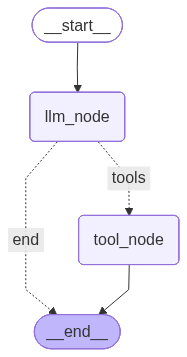

In [70]:
config={"configurable":{"thread_id":"1"}}
memory=InMemorySaver()
app=graph.compile(checkpointer=memory)
app

In [74]:
# res=await app.ainvoke({"messages":HumanMessage(content="What is the current price of silver ETF?")},config=config)
# for msg in res['messages']:
#     print(msg.pretty_print())

In [72]:
res=await app.ainvoke({"messages":HumanMessage(content="Hi there, myself NB")},config=config)
for msg in res['messages']:
    print(msg.pretty_print())

================================ Human Message =================================

What is the current price of silver ETF?
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (vvwmm3r29)
 Call ID: vvwmm3r29
  Args:
    query: current price of silver ETF
None
================================= Tool Message =================================
Name: tavily_search_results_json

[{'title': 'Silver ETF (SLV) Stock Price Today & Analysis | Buy on Gotrade', 'url': 'https://www.heygotrade.com/en/us-stock/slv', 'content': 'Home\n\nUS Stock\n\nBlog\n\nNews\n\nInsider\n\nMarket Outlook\n\nJoin us\n\nFAQ\n\nLegal central\n\nPress\n\nGlobal\n\nIndonesia\n\n# Silver ETF (SLV) Stock Price Today & Analysis\n\nSLV company logo\n\n### Valuation\n\n### Earnings Per Share\n\n### Income Statement\n\n### Dividend\n\n### Solvency\n\n## About Silver ETF\n\niShares Silver Trust (SLV) is the largest physically backed silver exchange traded f

In [73]:
res=await app.ainvoke({"messages":HumanMessage(content="Hi there whats my name?")},config=config)
for msg in res['messages']:
    print(msg.pretty_print())

================================ Human Message =================================

What is the current price of silver ETF?
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (vvwmm3r29)
 Call ID: vvwmm3r29
  Args:
    query: current price of silver ETF
None
================================= Tool Message =================================
Name: tavily_search_results_json

[{'title': 'Silver ETF (SLV) Stock Price Today & Analysis | Buy on Gotrade', 'url': 'https://www.heygotrade.com/en/us-stock/slv', 'content': 'Home\n\nUS Stock\n\nBlog\n\nNews\n\nInsider\n\nMarket Outlook\n\nJoin us\n\nFAQ\n\nLegal central\n\nPress\n\nGlobal\n\nIndonesia\n\n# Silver ETF (SLV) Stock Price Today & Analysis\n\nSLV company logo\n\n### Valuation\n\n### Earnings Per Share\n\n### Income Statement\n\n### Dividend\n\n### Solvency\n\n## About Silver ETF\n\niShares Silver Trust (SLV) is the largest physically backed silver exchange traded f

In [77]:
config={"configurable":{"thread_id":"2"}}
async for event in app.astream_events({"messages":HumanMessage(content="Hi there, its Nisarg")},config=config):
    if event['event']=="on_chat_model_stream":
        print(event['data']["chunk"].content,end="",flush=True)


Hello again Nisarg. How can I assist you today? Do you have any questions or topics you'd like to discuss?